# Problem 3.3 — Python translation

This notebook translates the Mathematica calculations into Python using NumPy, SciPy, Matplotlib, and optional `ipywidgets` controls.

It contains:

1. the RF Hamiltonian and its phase-space contours;
2. the exact pendulum solution in terms of Jacobi elliptic functions;
3. a unified treatment of libration, rotation, the separatrix, and the fixed points;
4. static and interactive plots; and
5. numerical checks of the initial conditions and energy conservation.

## Imports

The mathematical notation below uses the elliptic **modulus** $k$. SciPy's elliptic-function routines accept the parameter $m=k^2$, so every SciPy call passes `k**2` explicitly.

In [1]:
from dataclasses import dataclass
from typing import Callable

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipj, ellipk, ellipkinc

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("Optional interactive controls require ipywidgets: %pip install ipywidgets")

# plt.style.use("seaborn-v0_8-whitegrid")

import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## 1. RF Hamiltonian

The Mathematica definition is

$$
H(p_\phi,\phi;\psi_s,\Omega)
=\frac{p_\phi^2}{2}
+\frac{\Omega^2}{\cos\psi_s}
\left[\cos(\psi_s+\phi)-\cos\psi_s+\phi\sin\psi_s\right].
$$

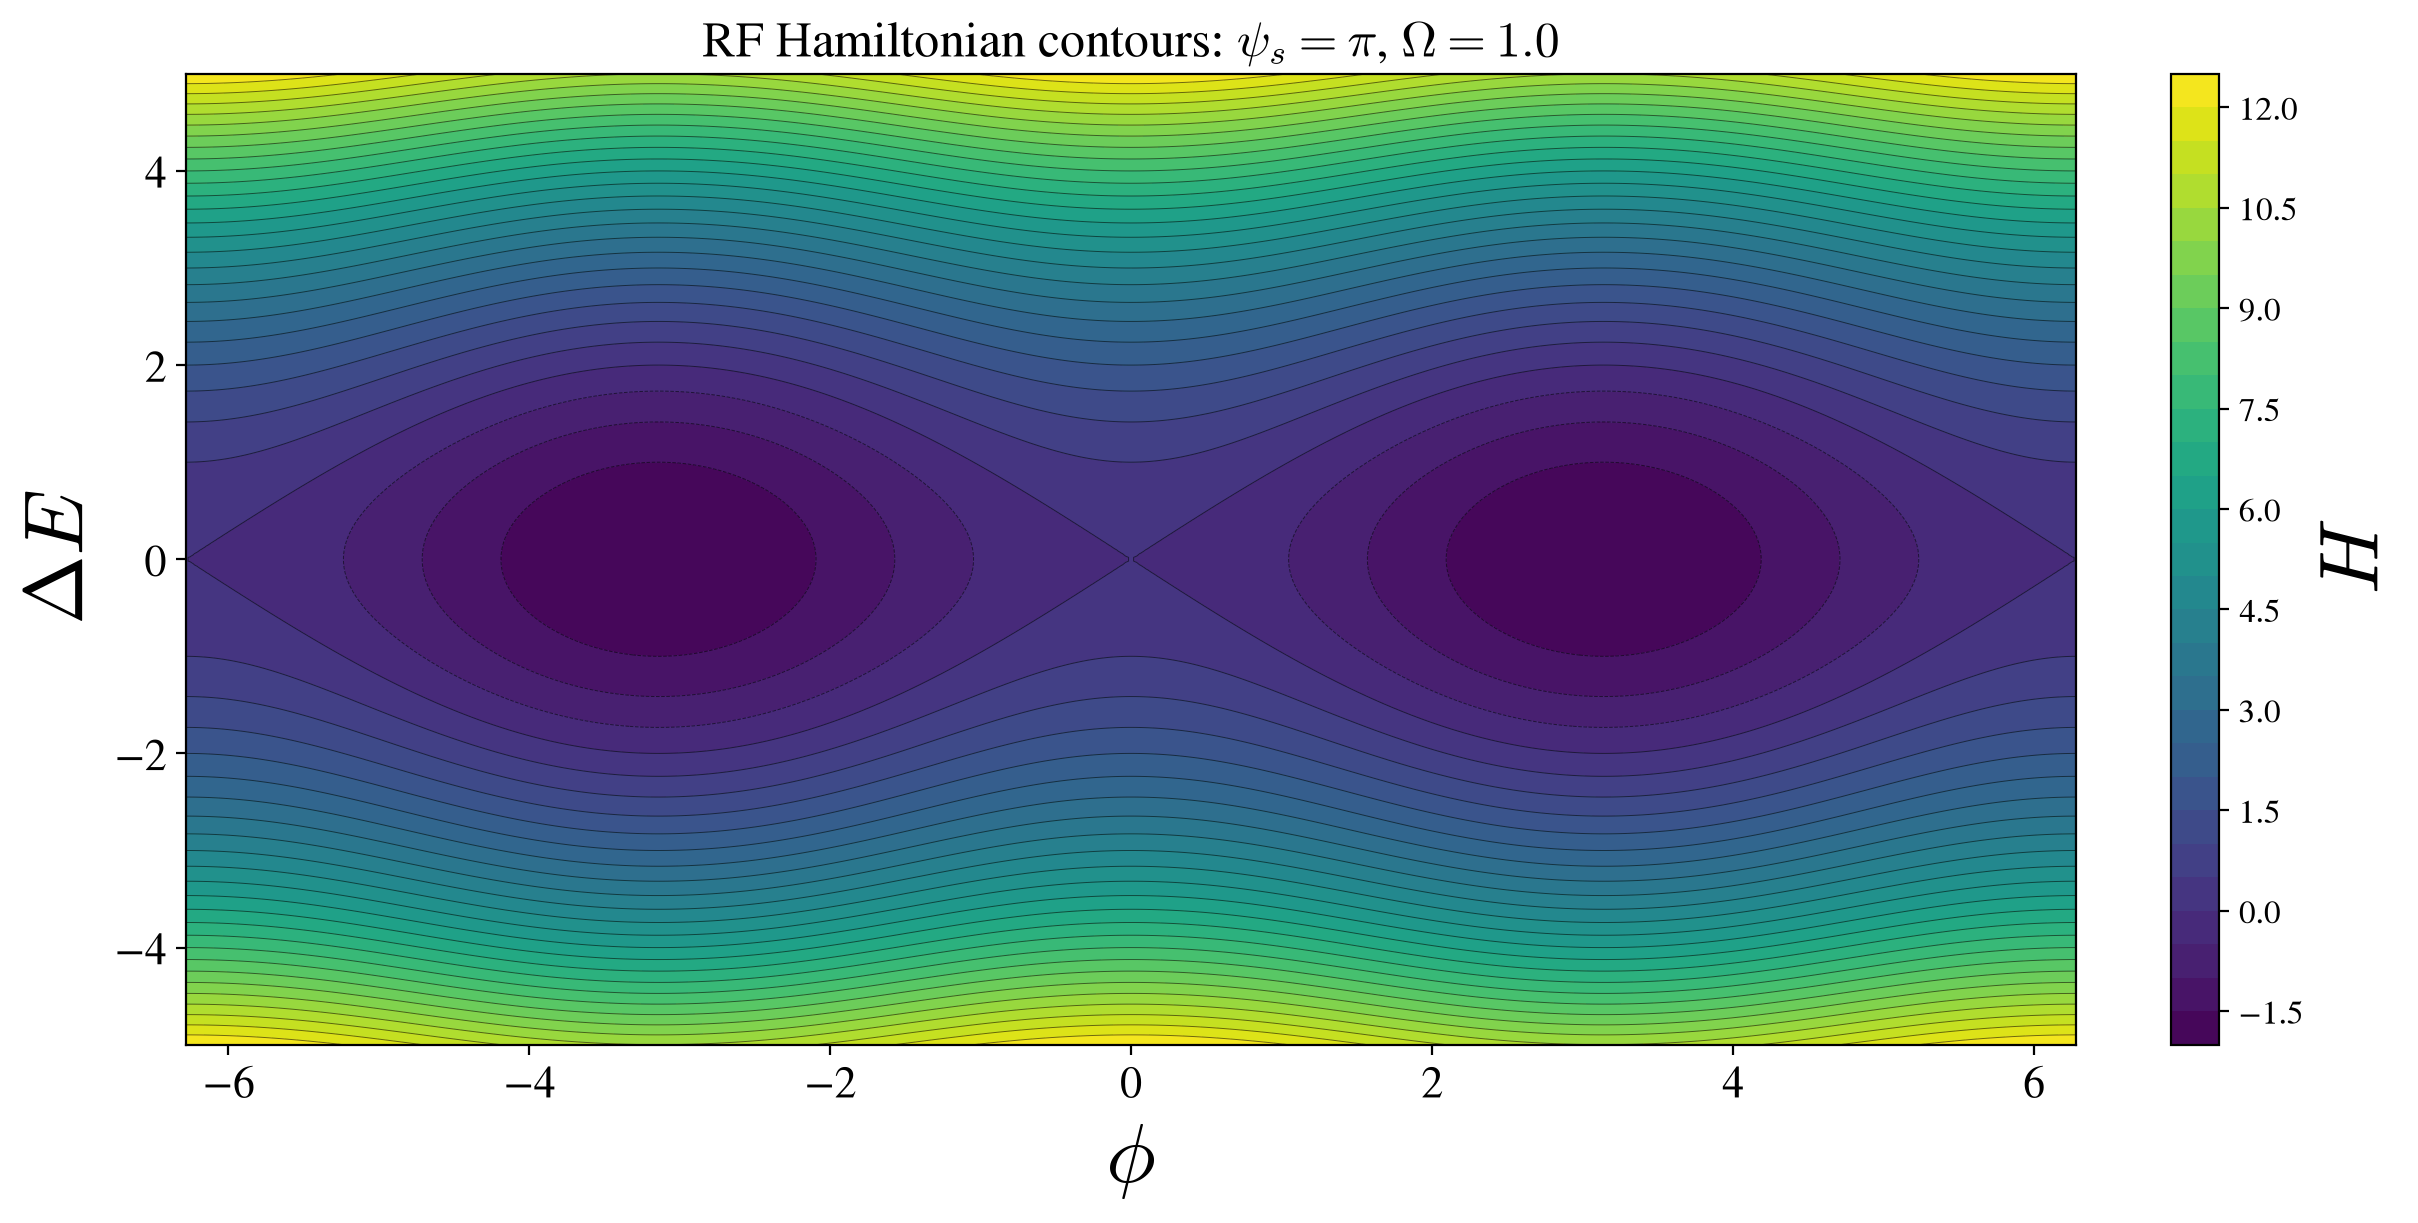

In [20]:
def rf_hamiltonian(p_phi, phi, psi_s, omega=1.0):
    """RF Hamiltonian from the original Mathematica notebook."""
    return (
        0.5 * np.asarray(p_phi) ** 2
        + omega**2
        / np.cos(psi_s)
        * (
            np.cos(psi_s + np.asarray(phi))
            - np.cos(psi_s)
            + np.asarray(phi) * np.sin(psi_s)
        )
    )


def plot_rf_hamiltonian(psi_s=np.pi, omega=1.0, levels=30):
    """Plot filled phase-space contours of the RF Hamiltonian."""
    phi = np.linspace(-2 * np.pi, 2 * np.pi, 500)
    p_phi = np.linspace(-5.0, 5.0, 260)
    PHI, P_PHI = np.meshgrid(phi, p_phi)
    H = rf_hamiltonian(P_PHI, PHI, psi_s, omega)

    fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
    filled = ax.contourf(PHI, P_PHI, H, levels=levels, cmap="viridis")
    ax.contour(PHI, P_PHI, H, levels=levels, colors="black", linewidths=0.35, alpha=0.55,)
    cb = fig.colorbar(filled, ax=ax,)
    cb.ax.set_ylabel(r"$H$", fontsize=30)
    cb.ax.tick_params(labelsize=12)
    ax.set(
        xlabel=r"$\phi$",
        ylabel=r"$\Delta E$",
        title=rf"RF Hamiltonian contours: $\psi_s={psi_s:.3f}$, $\Omega={omega:.2f}$",
        xlim=(-2 * np.pi, 2 * np.pi),
        ylim=(-5, 5),
    )

    ax = plt.gca()
    ax.set_xlabel(r"$\phi$", fontsize=30)
    ax.set_ylabel(r"$\Delta E$", fontsize=30)


    ax.tick_params(axis="both", which="major", labelsize=16)


    ax.set_title(r"RF Hamiltonian contours: $\psi_s=\pi$, $\Omega=1.0$", fontsize = 18)

    fig = plt.gcf()
    fig.set_dpi(200)

    return fig, ax


plot_rf_hamiltonian(psi_s=np.pi, omega=1.0, levels = 30)

plt.show()

In [21]:
# Mathematica Manipulate translated to an optional Jupyter widget.
if WIDGETS_AVAILABLE:
    def explore_rf_hamiltonian(psi_s):
        plot_rf_hamiltonian(psi_s=psi_s, omega=1.0)
        plt.show()

    interact(
        explore_rf_hamiltonian,
        psi_s=FloatSlider(
            value=np.pi,
            min=np.pi / 2 + 0.05,
            max=3 * np.pi / 2 - 0.05,
            step=0.02,
            description=r"psi_s",
            continuous_update=False,
        ),
    )
else:
    print("Skipping the RF widget because ipywidgets is not installed.")

interactive(children=(FloatSlider(value=3.141592653589793, continuous_update=False, description='psi_s', max=4…

## 2. Exact normalized-pendulum solution

The normalized Hamiltonian is

$$
E=\frac{P^2}{2}-\cos\theta,
$$

and Hamilton's equations are $\dot\theta=P$ and $\dot P=-\sin\theta$.

For bounded motion, $-1<E<1$, define

$$
k=\sqrt{\frac{1+E}{2}}, \qquad
T=4K(k),
$$

where $K(k)$ is the complete elliptic integral of the first kind. The solution is

$$
\theta(\tau)=2\sin^{-1}\!\left[k\,\operatorname{sn}(z_0+\tau,k)\right],
\qquad
P(\tau)=2k\,\operatorname{cn}(z_0+\tau,k).
$$

For rotational motion, $E>1$, the reciprocal modulus $k_r=1/\kappa<1$ is used, with $\kappa=\sqrt{(E+1)/2}$. The code also evaluates the $E=1$ separatrix analytically.

In [22]:
@dataclass(frozen=True)
class PendulumSolution:
    motion: str
    energy: float
    modulus: float
    period: float
    theta: Callable[[np.ndarray], np.ndarray]
    momentum: Callable[[np.ndarray], np.ndarray]


def pendulum_energy(theta, momentum):
    """E = P^2/2 - cos(theta)."""
    return 0.5 * np.asarray(momentum) ** 2 - np.cos(np.asarray(theta))


def wrap_angle(theta):
    """Map an angle to [-pi, pi)."""
    return (np.asarray(theta) + np.pi) % (2 * np.pi) - np.pi


def pendulum_solution(theta0, p0, tau0=0.0, tolerance=1e-10):
    """
    Return the exact trajectory for arbitrary initial conditions.

    The returned modulus is k for libration and the reciprocal modulus
    k_r = 1/kappa for rotation. SciPy receives m = k**2 internally.
    """
    theta0 = float(theta0)
    p0 = float(p0)
    tau0 = float(tau0)

    energy_value = float(pendulum_energy(theta0, p0))
    theta_wrapped = float(wrap_angle(theta0))
    theta_shift = theta0 - theta_wrapped

    # Stable fixed point. The reported 2*pi is the limiting small-amplitude period.
    if abs(energy_value + 1.0) <= tolerance:
        return PendulumSolution(
            motion="Stable fixed point",
            energy=energy_value,
            modulus=0.0,
            period=2 * np.pi,
            theta=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)) + theta0,
            momentum=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)),
        )

    # Libration: -1 < E < 1.
    if energy_value < 1.0 - tolerance:
        k = np.sqrt((1.0 + energy_value) / 2.0)
        m = k**2

        sn0 = np.clip(np.sin(theta_wrapped / 2.0) / k, -1.0, 1.0)
        cn0 = np.clip(p0 / (2.0 * k), -1.0, 1.0)
        amplitude0 = np.arctan2(sn0, cn0)
        z0 = ellipkinc(amplitude0, m)

        def theta(tau):
            z = z0 + np.asarray(tau, dtype=float) - tau0
            sn, _, _, _ = ellipj(z, m)
            return theta_shift + 2.0 * np.arcsin(np.clip(k * sn, -1.0, 1.0))

        def momentum(tau):
            z = z0 + np.asarray(tau, dtype=float) - tau0
            _, cn, _, _ = ellipj(z, m)
            return 2.0 * k * cn

        return PendulumSolution(
            motion="Libration",
            energy=energy_value,
            modulus=k,
            period=4.0 * ellipk(m),
            theta=theta,
            momentum=momentum,
        )

    # Rotation: E > 1.
    if energy_value > 1.0 + tolerance:
        direction = 1.0 if p0 >= 0.0 else -1.0
        kappa = np.sqrt((energy_value + 1.0) / 2.0)
        k_reciprocal = 1.0 / kappa
        m = k_reciprocal**2
        z0 = ellipkinc(theta_wrapped / 2.0, m)

        def theta(tau):
            z = z0 + direction * kappa * (np.asarray(tau, dtype=float) - tau0)
            _, _, _, amplitude = ellipj(z, m)
            return theta_shift + 2.0 * amplitude

        def momentum(tau):
            z = z0 + direction * kappa * (np.asarray(tau, dtype=float) - tau0)
            _, _, dn, _ = ellipj(z, m)
            return 2.0 * direction * kappa * dn

        return PendulumSolution(
            motion="Rotation",
            energy=energy_value,
            modulus=k_reciprocal,
            period=2.0 * ellipk(m) / kappa,
            theta=theta,
            momentum=momentum,
        )

    # Separatrix: E = 1.
    if abs(p0) < tolerance and abs(abs(theta_wrapped) - np.pi) < 1e-8:
        return PendulumSolution(
            motion="Unstable fixed point",
            energy=energy_value,
            modulus=1.0,
            period=np.inf,
            theta=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)) + theta0,
            momentum=lambda tau: np.zeros_like(np.asarray(tau, dtype=float)),
        )

    direction = 1.0 if p0 >= 0.0 else -1.0
    crossing_time = tau0 - direction * np.log(np.tan((np.pi + theta_wrapped) / 4.0))

    def theta(tau):
        exponent = direction * (np.asarray(tau, dtype=float) - crossing_time)
        return theta_shift + 4.0 * np.arctan(np.exp(np.clip(exponent, -700, 700))) - np.pi

    def momentum(tau):
        return 2.0 * direction / np.cosh(np.asarray(tau, dtype=float) - crossing_time)

    return PendulumSolution(
        motion="Separatrix",
        energy=energy_value,
        modulus=1.0,
        period=np.inf,
        theta=theta,
        momentum=momentum,
    )

### Libration example from the Mathematica notebook

For $\theta_0=0.7$ and $P_0=0.5$, Mathematica returned

$$
(E,k,T)=(-0.6398421873,\ 0.4243570506,\ 6.5988676377).
$$

In [23]:
theta0_value = 0.7
p0_value = 0.5

example = pendulum_solution(theta0_value, p0_value)
print(f"Energy  = {example.energy:.10f}")
print(f"Modulus = {example.modulus:.10f}")
print(f"Period  = {example.period:.10f}")

Energy  = -0.6398421873
Modulus = 0.4243570506
Period  = 6.5988676377


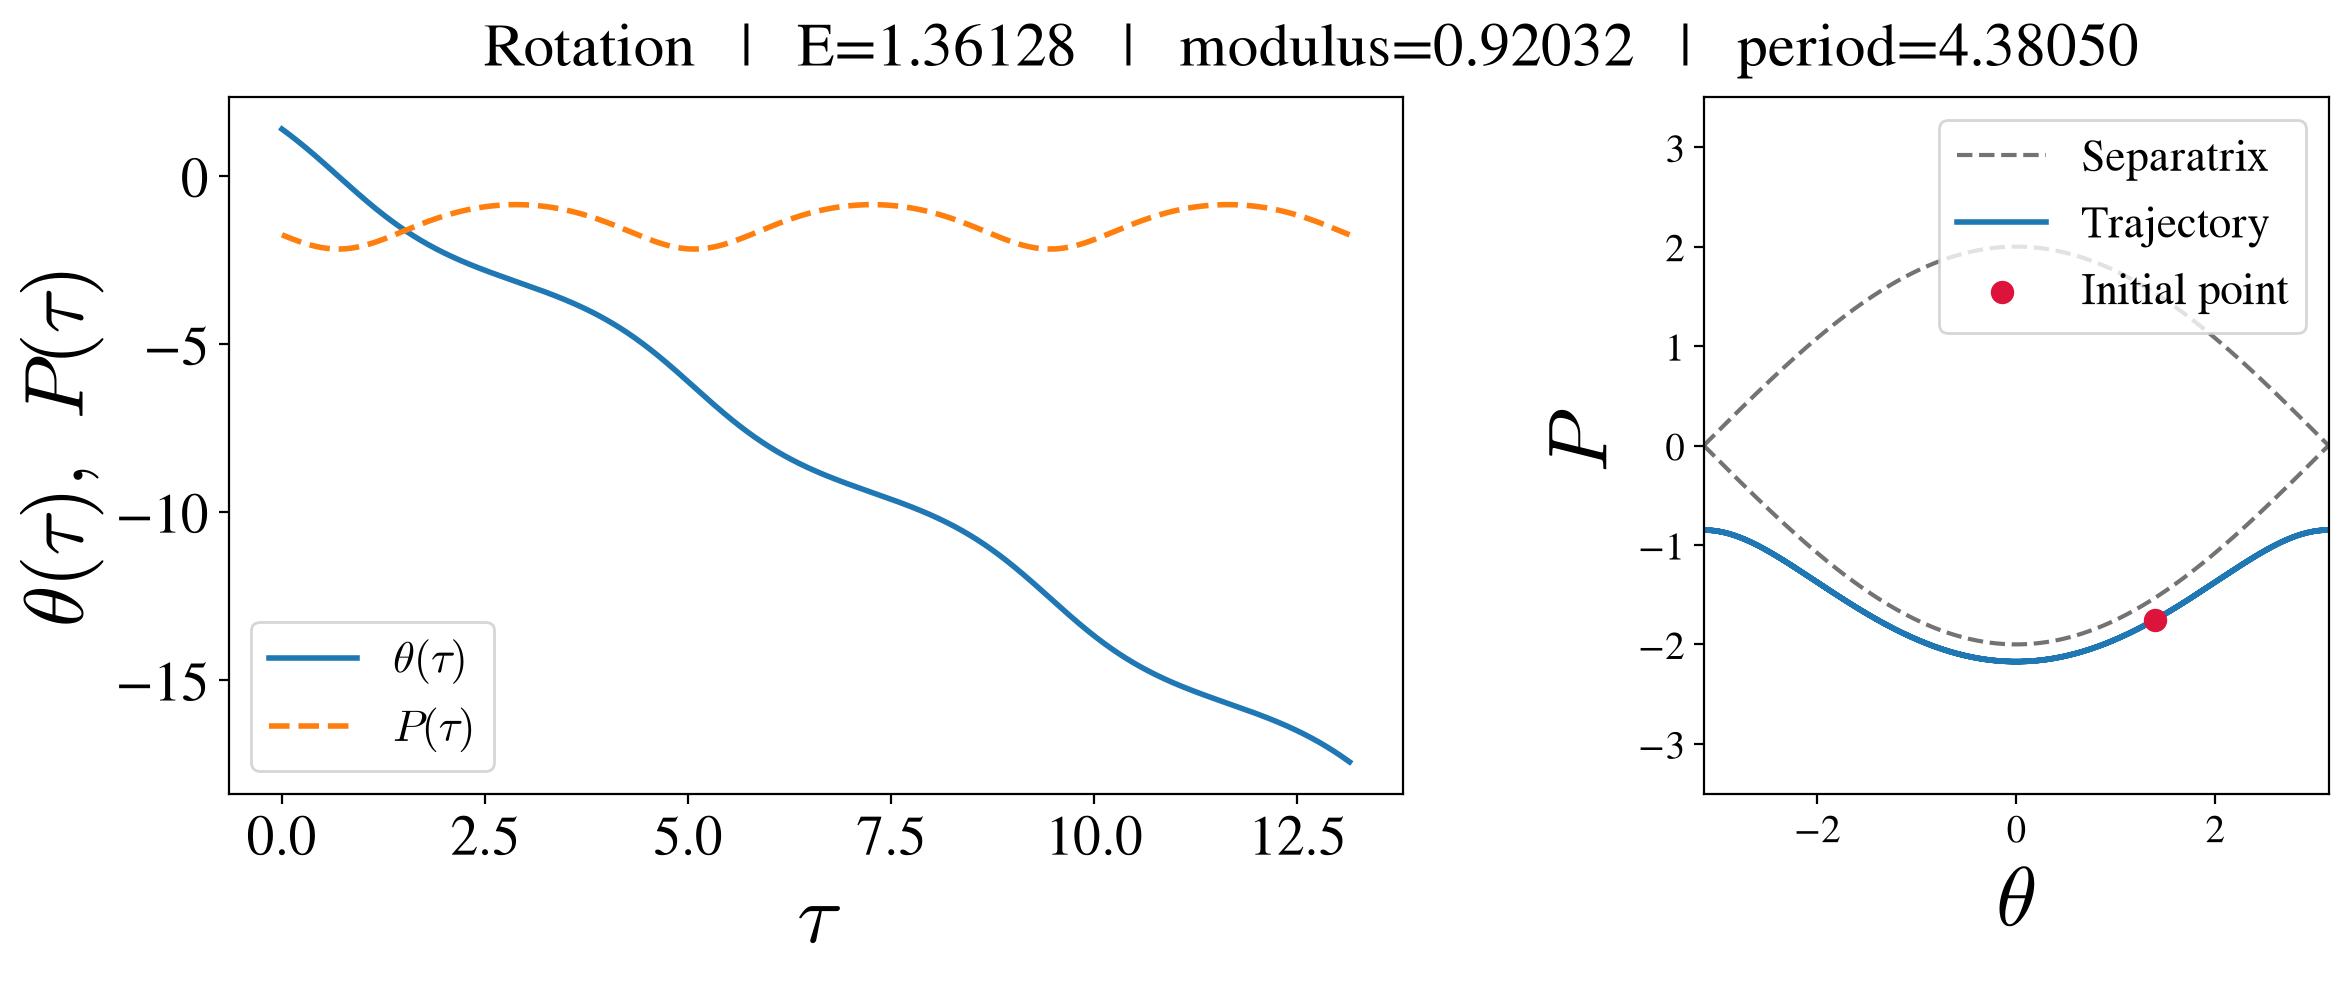

In [41]:
def plot_pendulum(theta0=0.7, p0=0.5, n_periods=3, points_per_period=700):
    """Plot theta(tau), P(tau), and the phase-space trajectory."""
    solution = pendulum_solution(theta0, p0)
    characteristic_time = solution.period if np.isfinite(solution.period) else 10.0
    tau_max = n_periods * characteristic_time
    n_points = max(1200, int(points_per_period * n_periods))
    tau = np.linspace(0.0, tau_max, n_points)

    theta = np.asarray(solution.theta(tau))
    momentum = np.asarray(solution.momentum(tau))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

    axes[0].plot(tau, theta, label=r"$\theta(\tau)$", linewidth=2)
    axes[0].plot(tau, momentum, label=r"$P(\tau)$", linewidth=2, linestyle="--")
    axes[0].set(xlabel=r"$\tau$", ylabel=r"$\theta(\tau),\ P(\tau)$")
    axes[0].set_xlabel(r"$\tau$", fontsize=30)
    axes[0].set_ylabel(r"$\theta(\tau),\ P(\tau)$", fontsize=30)
    axes[0].tick_params(axis="both", which="major", labelsize=20)
    axes[0].legend(fontsize=16)

    phase_angle = np.asarray(wrap_angle(theta))
    phase_momentum = momentum.copy()
    # Do not connect a rotational trajectory across the +/-pi plotting cut.
    jumps = np.where(np.abs(np.diff(phase_angle)) > np.pi)[0] + 1
    phase_angle[jumps] = np.nan
    phase_momentum[jumps] = np.nan

    theta_sep = np.linspace(-np.pi, np.pi, 800)
    p_sep = 2.0 * np.cos(theta_sep / 2.0)
    axes[1].plot(theta_sep, p_sep, "--", color="0.45", label="Separatrix")
    axes[1].plot(theta_sep, -p_sep, "--", color="0.45")
    axes[1].plot(phase_angle, phase_momentum, linewidth=2, label="Trajectory")
    axes[1].scatter([wrap_angle(theta0)], [p0], s=55, color="crimson", zorder=5, label="Initial point")
    axes[1].set(
        xlabel=r"$\theta$",
        ylabel=r"$P$",
        xlim=(-np.pi, np.pi),
        ylim=(-3.5, 3.5),
    )
    axes[1].set_xlabel(r"$\theta$", fontsize=30)
    axes[1].set_ylabel(r"$P$", fontsize=30)
    axes[1].tick_params(axis="both", which="major", labelsize=14)
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].legend(loc="upper right",fontsize = 16)

    period_text = f"{solution.period:.5f}" if np.isfinite(solution.period) else r"$\infty$"
    fig.suptitle(
        f"{solution.motion}   |   E={solution.energy:.5f}   |   "
        f"modulus={solution.modulus:.5f}   |   period={period_text}",
        fontsize=22,
    )
    fig.set_dpi(200)
    return fig, solution


plot_pendulum(theta0=theta0_value*2, p0=-3.5*p0_value, n_periods=3)
plt.show()

## 3. Interactive initial-condition explorer

This is the Python/Jupyter equivalent of the final Mathematica `Manipulate`. It automatically selects the correct analytical solution when the initial conditions move between the bounded, rotational, separatrix, and fixed-point regimes.

In [ ]:
if WIDGETS_AVAILABLE:
    def explore_pendulum(theta0, p0, n_periods):
        plot_pendulum(theta0=theta0, p0=p0, n_periods=n_periods)
        plt.show()

    interact(
        explore_pendulum,
        theta0=FloatSlider(
            value=0.7,
            min=-np.pi,
            max=np.pi,
            step=0.01,
            description=r"theta_0",
            continuous_update=False,
        ),
        p0=FloatSlider(
            value=0.5,
            min=-3.0,
            max=3.0,
            step=0.01,
            description=r"P_0",
            continuous_update=False,
        ),
        n_periods=IntSlider(
            value=3,
            min=1,
            max=10,
            step=1,
            description="periods",
            continuous_update=False,
        ),
    )
else:
    print("Skipping the pendulum widget because ipywidgets is not installed.")

interactive(children=(FloatSlider(value=0.7, continuous_update=False, description='theta_0', max=3.14159265358…

## 4. Verification

The following cell checks representative initial conditions in every motion regime. It verifies that the analytical functions reproduce $(\theta_0,P_0)$ at $\tau=0$ and conserve the Hamiltonian energy.

In [8]:
test_cases = [
    ("Libration", 0.7, 0.5),
    ("Rotation", 0.7, 2.0),
    ("Separatrix", 0.0, 2.0),
    ("Stable fixed point", 0.0, 0.0),
    ("Unstable fixed point", np.pi, 0.0),
]

print(f"{'motion':<23} {'theta(0)-theta0':>18} {'P(0)-P0':>14} {'max |Delta E|':>16}")
print("-" * 75)

for expected_motion, theta0, p0 in test_cases:
    solution = pendulum_solution(theta0, p0)
    assert solution.motion == expected_motion

    theta_error = float(solution.theta(0.0) - theta0)
    p_error = float(solution.momentum(0.0) - p0)

    sample_time = solution.period if np.isfinite(solution.period) else 10.0
    tau = np.linspace(0.0, 2.0 * sample_time, 1000)
    energy_along_trajectory = pendulum_energy(solution.theta(tau), solution.momentum(tau))
    max_energy_error = np.max(np.abs(energy_along_trajectory - solution.energy))

    assert abs(theta_error) < 1e-9
    assert abs(p_error) < 1e-9
    assert max_energy_error < 1e-9

    print(
        f"{solution.motion:<23} {theta_error:18.3e} "
        f"{p_error:14.3e} {max_energy_error:16.3e}"
    )

print("\nAll checks passed.")

motion                     theta(0)-theta0        P(0)-P0    max |Delta E|
---------------------------------------------------------------------------
Libration                       -3.331e-16     -1.110e-16        3.331e-16
Rotation                         2.220e-16      0.000e+00        6.883e-15
Separatrix                       0.000e+00      0.000e+00        8.882e-16
Stable fixed point               0.000e+00      0.000e+00        0.000e+00
Unstable fixed point             0.000e+00      0.000e+00        0.000e+00

All checks passed.


In [37]:
# Create a Gaussian grid of initial conditions for the pendulum and plot the resulting trajectories as a function of turns
# Center of the distribution (X_mean, Y_mean)
mean = [0, 0] 

# Covariance matrix defining the spread and relationship
# [[Variance_X, Covariance_XY], [Covariance_YX, Variance_Y]]
covariance = [[(np.pi / 6) ** 2, 0], 
              [0, 0.1]]  # Variance in theta and p_phi

# Generate 5,000 random coordinates
samples = np.random.multivariate_normal(mean, covariance, size=5000)

theta0_values, p0_values = samples[:, 0], samples[:, 1]

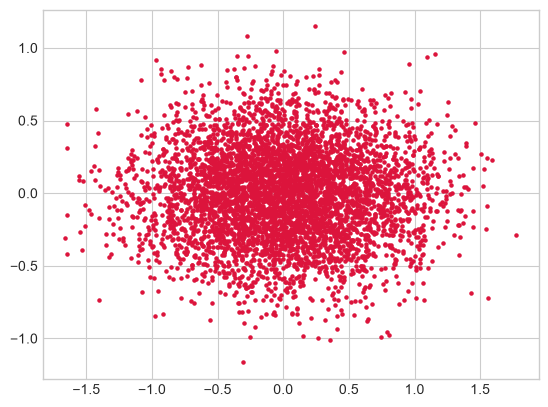

In [38]:
plt.scatter(theta0_values, p0_values, color="crimson", s=5)

In [53]:
# Get solutions as for every initial condition and store the results
solutions = [pendulum_solution(theta0, p0) for theta0, p0 in zip(theta0_values, p0_values)]

# Defimne time grid to calculate the trajectories for each initial condition
tau_grid = np.linspace(0, 10, 1000)  # Adjust the time range as needed

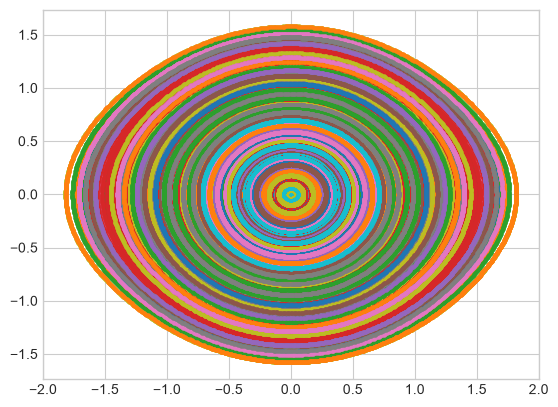

In [54]:
for solution in solutions:
    plt.scatter(solution.theta(tau_grid), solution.momentum(tau_grid), s=5)  # Example of evaluating the theta and p_phi functions for each solution

In [55]:
# Calculate all solutions as function of time and store them in a list
solutions_over_time = [(solution.theta(tau_grid), solution.momentum(tau_grid)) for solution in solutions]

In [56]:
# Histogram the theta values at every time step to visualize the distribution of angles over time
# The bins should be set to cover the range of theta values, which is typically from -pi to pi for a pendulum.
# Save frequency distributions of theta at each time step
histograms_over_time = []
for i, tau in enumerate(tau_grid):
    theta_values_at_tau = [solution[0][i] for solution in solutions_over_time]
    histogram, bin_edges = np.histogram(theta_values_at_tau, bins=100, range=(-np.pi, np.pi))
    histograms_over_time.append(histogram)

histograms_over_time = np.array(histograms_over_time)

Text(0, 0.5, '$\\tau$')

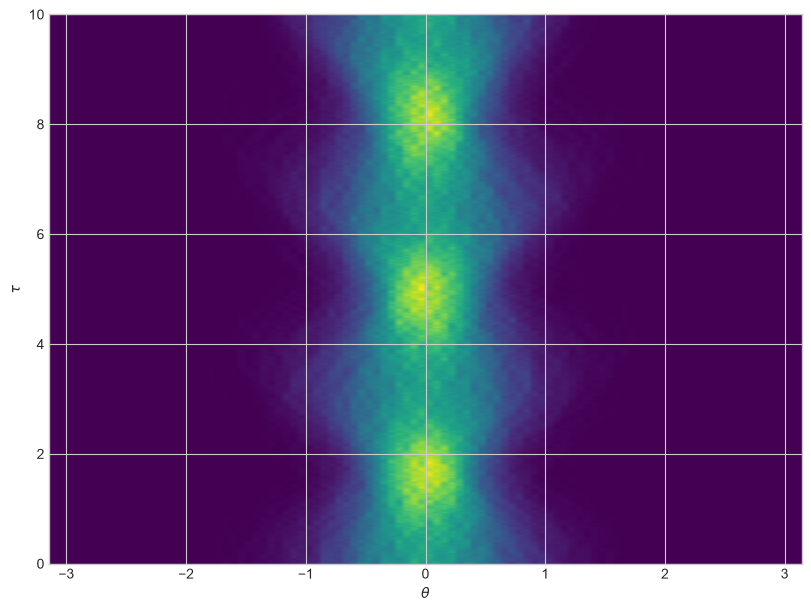

In [59]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
ax.imshow(histograms_over_time, extent=[-np.pi, np.pi, tau_grid[0], tau_grid[-1]], aspect='auto', origin='lower', cmap='viridis')

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\tau$")
